In [1]:
import os
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

In [2]:
folder_path = "./"  # Change this to your folder path

# Function to read .dat files
def read_dat_file(file_path):
    with open(file_path, "r") as file:
        lines = file.readlines()

    try:
        start_index = lines.index("[Curve Data]\n") + 2  # Find start of data
    except ValueError:
        print(f"Error: '[Curve Data]' not found in {file_path}")
        return pd.DataFrame()

    # Extract valid data
    data = []
    for line in lines[start_index:]:
        line = line.strip()
        if not line or line.startswith("HeaderEnd"):  
            continue
        parts = line.split(";")
        if len(parts) >= 4:  # Ensure at least 4 valid columns exist
            data.append(parts)

    # Define column names
    columns = ["Session Time", "Volume (liters)", "Balloon Valve Status", "Patient Switch", "Gating Mode", "Gating Status", "Relay State"]
    df = pd.DataFrame(data, columns=columns)

    # Convert numeric columns
    df["Session Time"] = pd.to_numeric(df["Session Time"], errors="coerce")
    df["Volume (liters)"] = pd.to_numeric(df["Volume (liters)"], errors="coerce")
    df["Balloon Valve Status"] = pd.to_numeric(df["Balloon Valve Status"], errors="coerce")
    df["Patient Switch"] = pd.to_numeric(df["Patient Switch"], errors="coerce")

    # Remove NaN values
    df = df.dropna(subset=["Session Time"])

    return df

# Load all .dat files
dataframes = []
for file in os.listdir(folder_path):
    if file.endswith(".dat"):
        df = read_dat_file(os.path.join(folder_path, file))
        if not df.empty:
            dataframes.append(df)

# Combine all data
if dataframes:
    final_df = pd.concat(dataframes, ignore_index=True)
    print("Final Processed Data:\n", final_df.head(10))
else:
    print("No valid data found.")

Final Processed Data:
    Session Time  Volume (liters)  Balloon Valve Status  Patient Switch  \
0          4.88            0.312                     1               0   
1          4.90            0.320                     1               0   
2          4.92            0.328                     1               0   
3          4.94            0.336                     1               0   
4          4.96            0.344                     1               0   
5          4.98            0.348                     1               0   
6          5.00            0.356                     1               0   
7          5.02            0.364                     1               0   
8          5.04            0.372                     1               0   
9          5.06            0.376                     1               0   

      Gating Mode Gating Status Relay State  
0  Manual Overide                            
1              -             -            -  
2              -        

In [3]:
final_df

,Session Time,Volume (liters),Balloon Valve Status,Patient Switch,Gating Mode,Gating Status,Relay State
0,4.88,0.312,1,0,Manual Overide,,
1,4.90,0.320,1,0,-,-,-
2,4.92,0.328,1,0,-,-,-
3,4.94,0.336,1,0,-,-,-
4,4.96,0.344,1,0,-,-,-
...,...,...,...,...,...,...,...
1426949,2812.30,0.132,1,1,-,-,-
1426950,2812.32,0.124,1,1,-,-,-
1426951,2812.34,0.120,1,1,-,-,-
1426952,2812.36,0.112,1,1,-,-,-


In [4]:
 final_df.to_csv("output.dat", sep=",", index=False, header=True)

In [5]:
average_breathing = final_df.groupby("Session Time")["Volume (liters)"].mean()
print(average_breathing.head(1000))

Session Time
0.02     0.000000
0.04     0.000000
0.06     0.000000
0.08     0.000000
0.10     0.000000
           ...   
19.92    0.147579
19.94    0.148632
19.96    0.149474
19.98    0.150316
20.00    0.151579
Name: Volume (liters), Length: 1000, dtype: float64


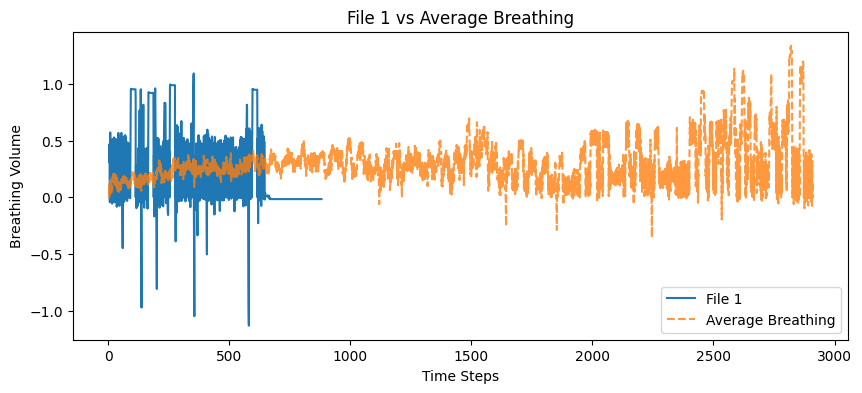

C:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


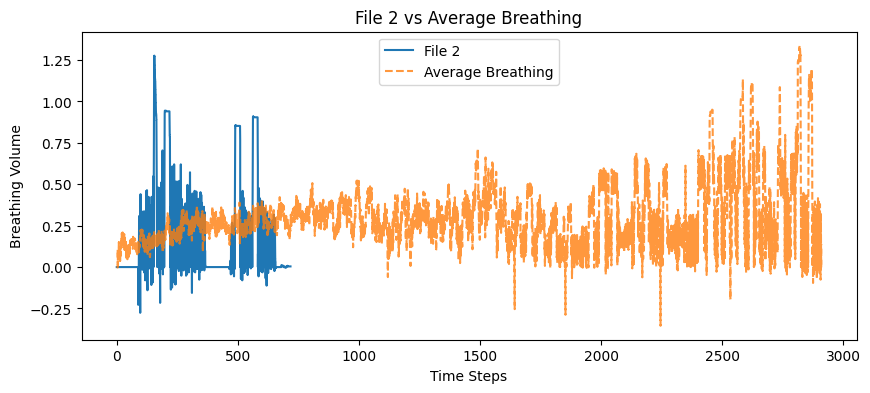

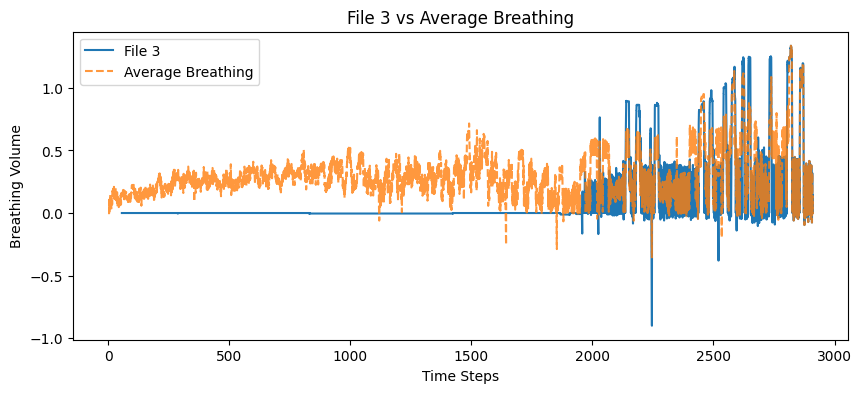

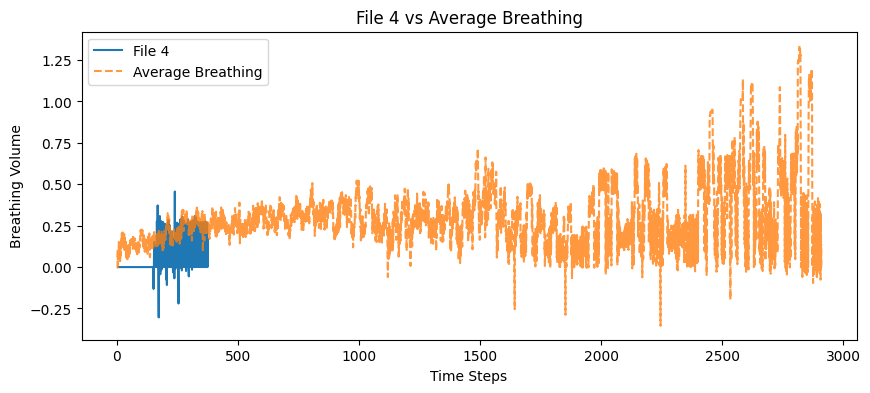

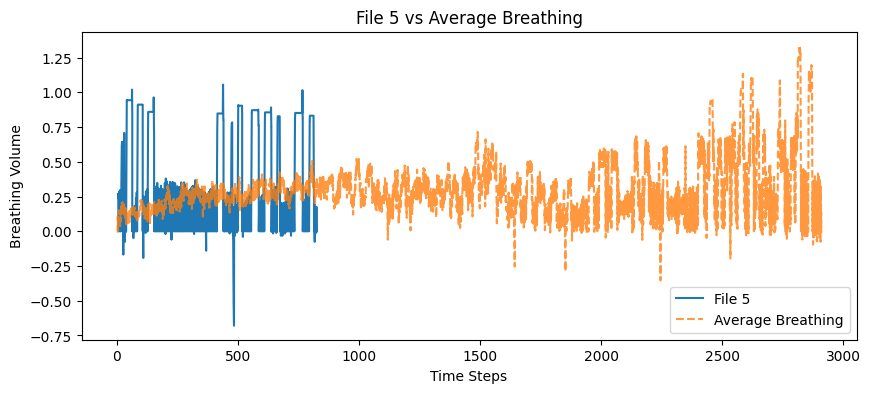

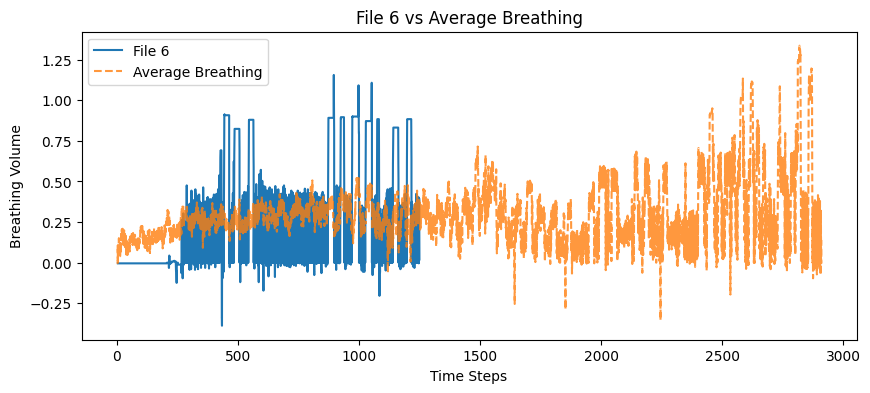

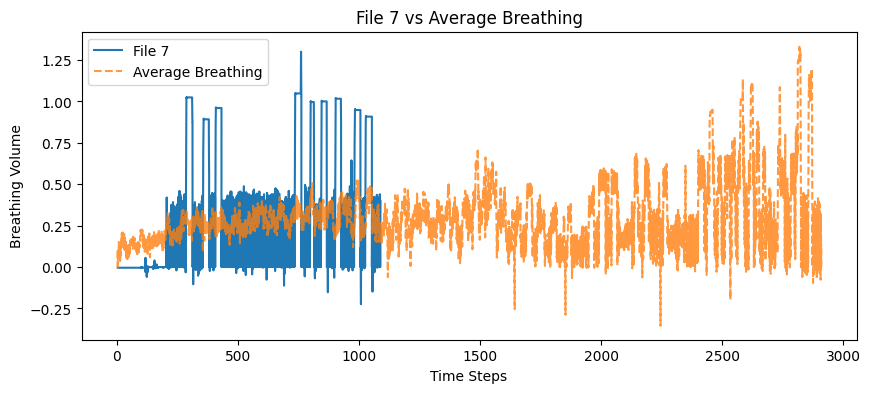

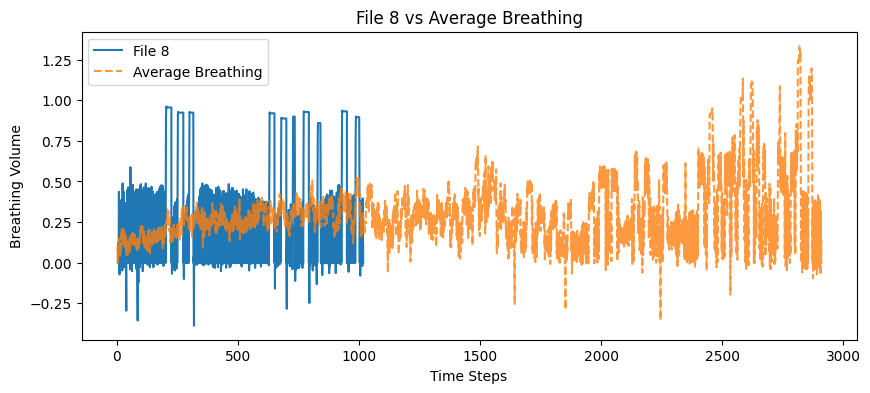

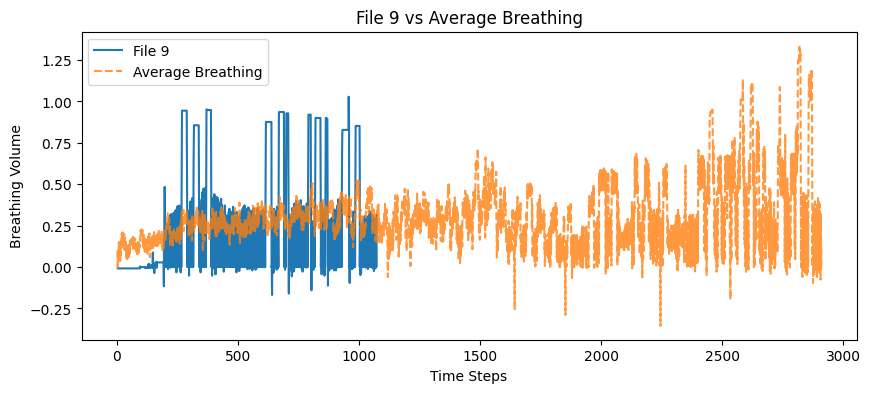

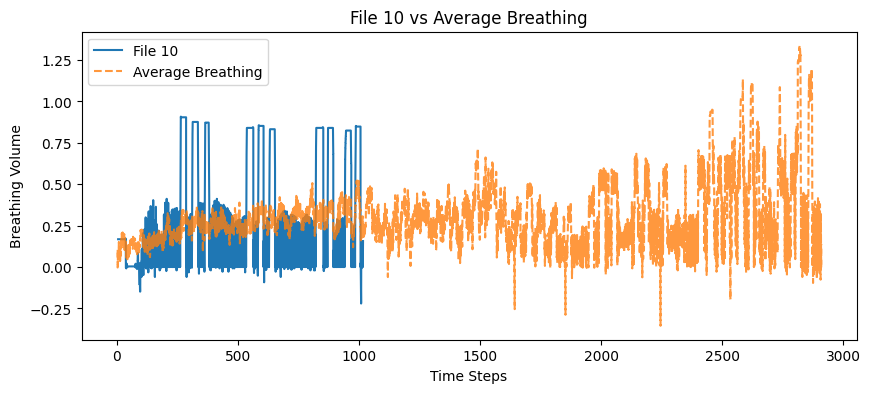

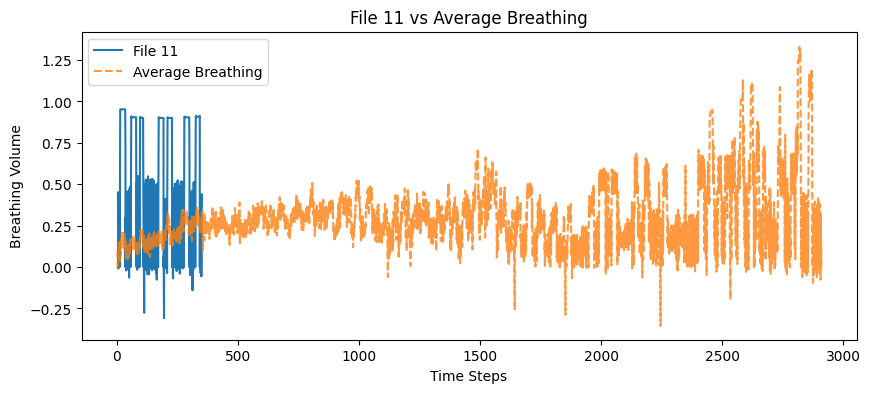

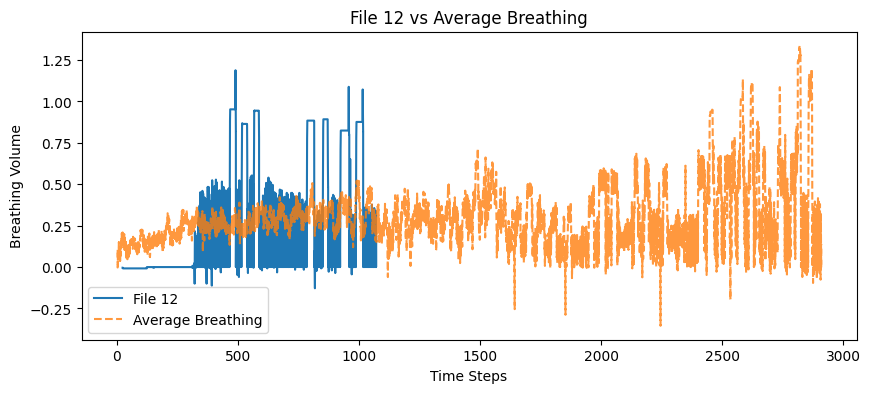

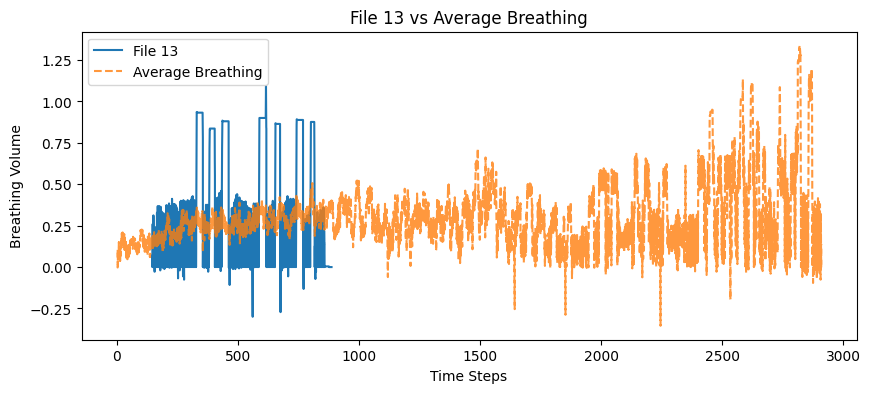

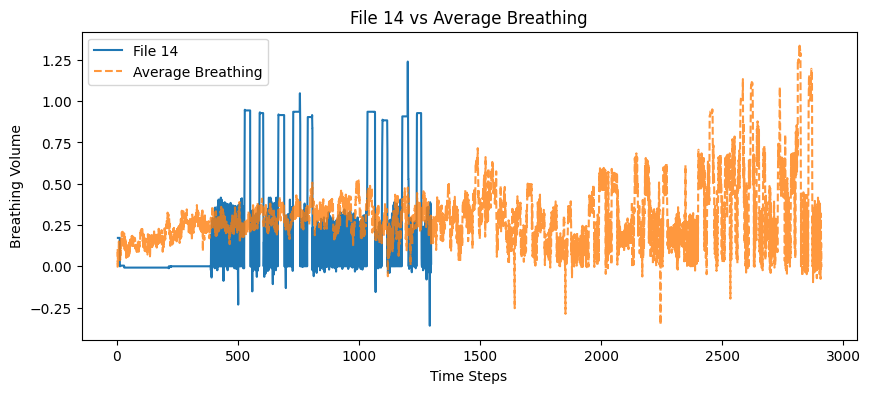

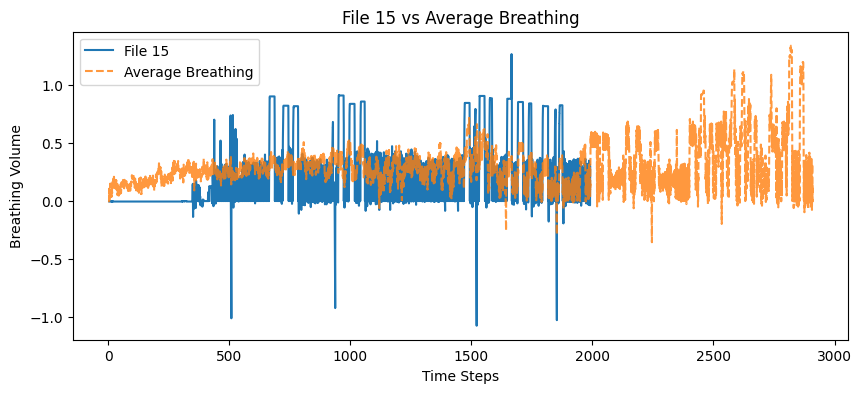

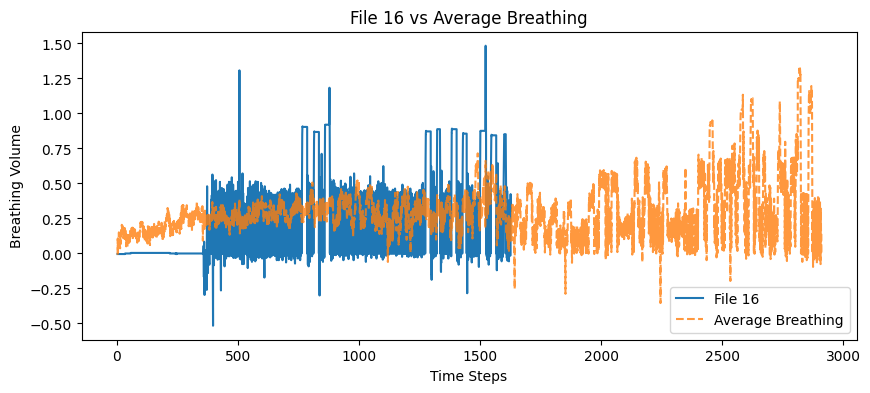

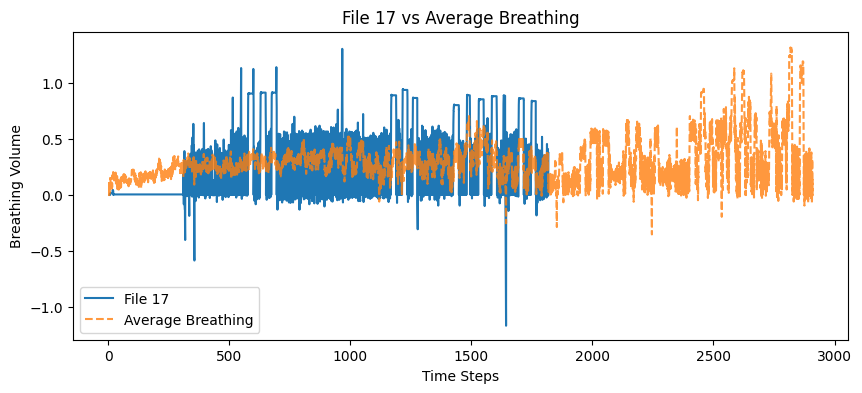

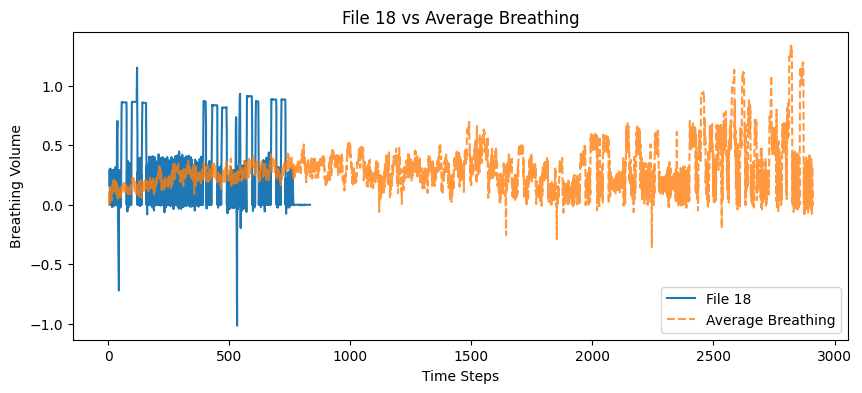

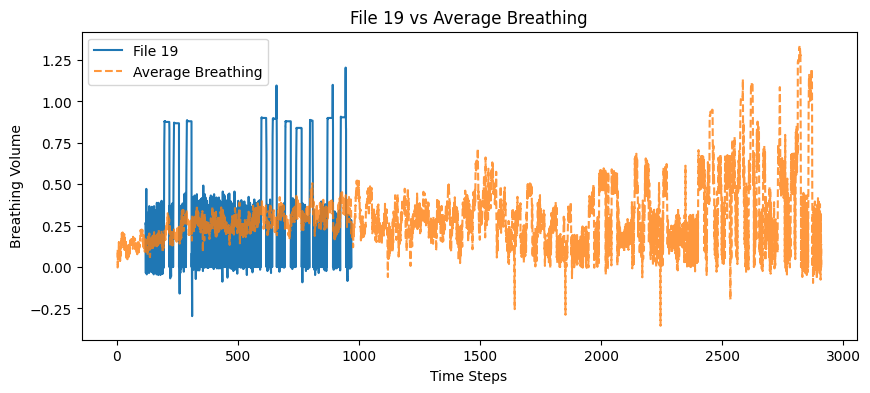

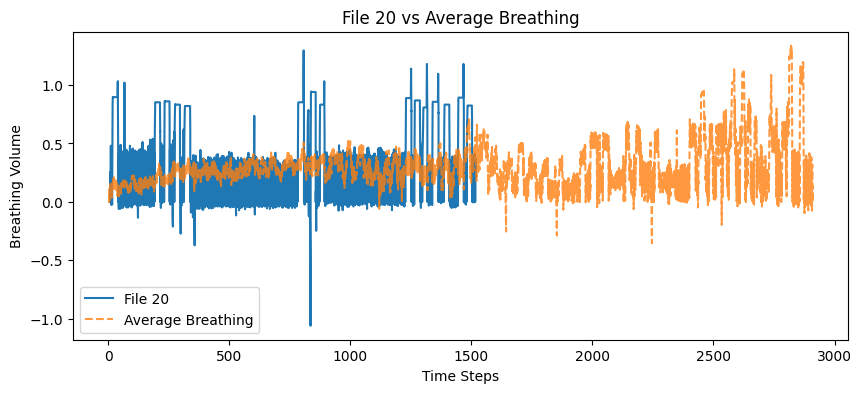

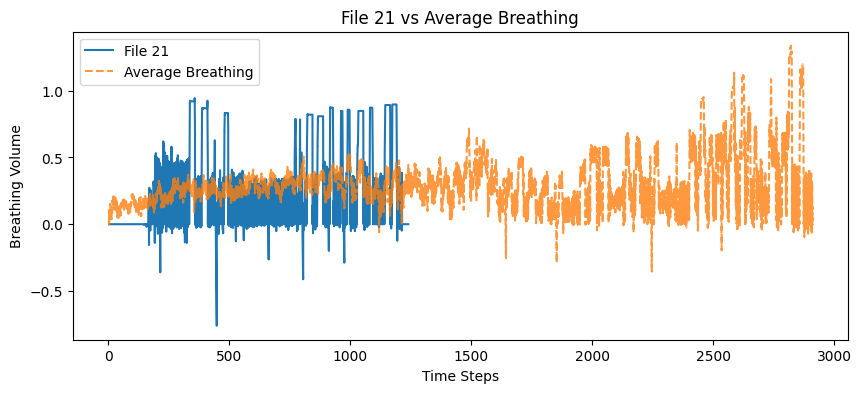

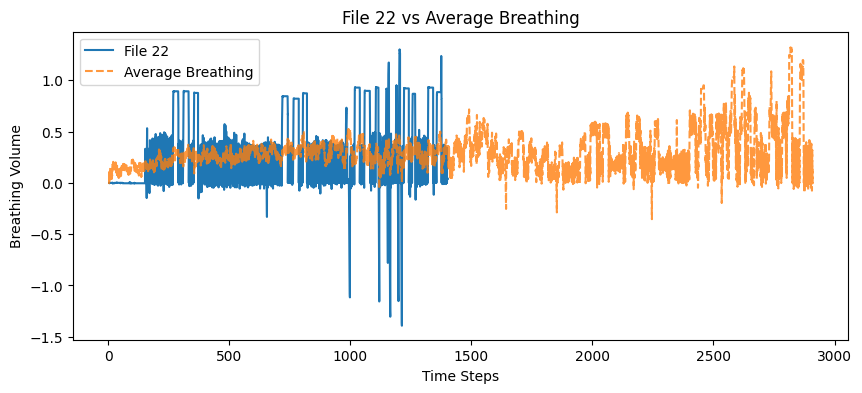

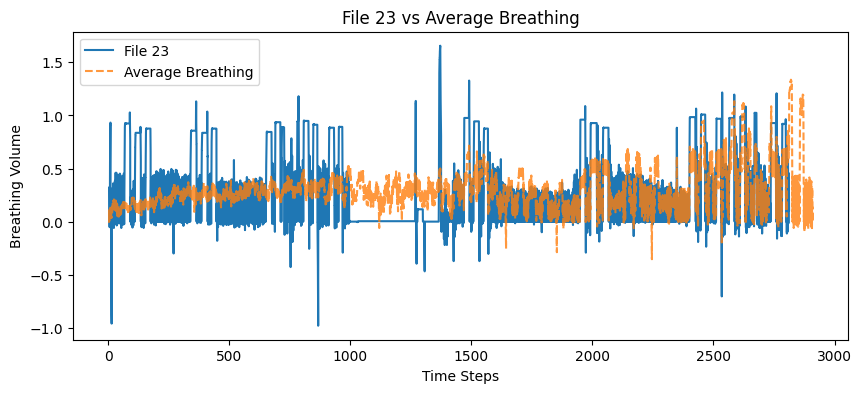

File 1 Correlation with Average: -0.023
File 2 Correlation with Average: nan
File 3 Correlation with Average: nan
File 4 Correlation with Average: nan
File 5 Correlation with Average: 0.158
File 6 Correlation with Average: 0.000
File 7 Correlation with Average: 0.000
File 8 Correlation with Average: 0.055
File 9 Correlation with Average: 0.000
File 10 Correlation with Average: -0.122
File 11 Correlation with Average: 0.085
File 12 Correlation with Average: -0.139
File 13 Correlation with Average: -0.049
File 14 Correlation with Average: -0.227
File 15 Correlation with Average: -0.045
File 16 Correlation with Average: 0.205
File 17 Correlation with Average: -0.038
File 18 Correlation with Average: 0.368
File 19 Correlation with Average: -0.098
File 20 Correlation with Average: 0.060
File 21 Correlation with Average: nan
File 22 Correlation with Average: -0.148
File 23 Correlation with Average: -0.032


In [6]:
correlations = []
for i, df in enumerate(dataframes):
    correlation = df["Volume (liters)"].corr(average_breathing)
    correlations.append(correlation)

    # Plot comparison
    plt.figure(figsize=(10, 4))
    plt.plot(df["Session Time"], df["Volume (liters)"], label=f"File {i+1}")
    plt.plot(average_breathing, label="Average Breathing", linestyle="dashed", alpha=0.8)
    plt.xlabel("Time Steps")
    plt.ylabel("Breathing Volume")
    plt.title(f"File {i+1} vs Average Breathing")
    plt.legend()
    plt.show()

# Print Correlation Scores
for i, corr in enumerate(correlations):
    print(f"File {i+1} Correlation with Average: {corr:.3f}")

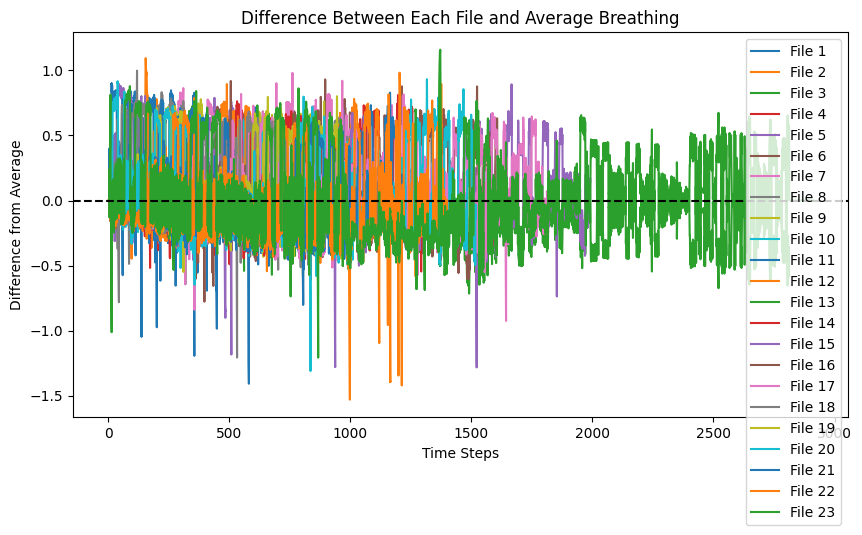

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for i, df in enumerate(dataframes):
    # Merge individual file with the average data on "Session Time"
    merged_df = df.merge(average_breathing, on="Session Time", how="inner", suffixes=("", "_avg"))

    # Compute the difference only for matching time steps
    difference = merged_df["Volume (liters)"] - merged_df["Volume (liters)_avg"]

    # Ensure x (Session Time) and y (Difference) have the same length
    plt.plot(merged_df["Session Time"], difference, label=f"File {i+1}")

plt.axhline(0, color="black", linestyle="dashed")  # Zero reference line
plt.xlabel("Time Steps")
plt.ylabel("Difference from Average")
plt.title("Difference Between Each File and Average Breathing")
plt.legend()
plt.show()


In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

for i, df in enumerate(dataframes):
    # Ensure average_breathing and df["Volume (liters)"] are properly indexed
    average_breathing = average_breathing.reset_index(drop=True)
    df = df.reset_index(drop=True)

    len_avg = len(average_breathing)
    len_df = len(df["Volume (liters)"])

    print(f"File {i+1} - Length of average_breathing: {len_avg}, Length of df: {len_df}")

    min_length = min(len_avg, len_df)

    y_true = np.array(average_breathing.iloc[:min_length])  # Use iloc to slice safely
    y_pred = np.array(df["Volume (liters)"].iloc[:min_length])  # Use iloc to slice safely

    # Ensure both arrays are 1D and have matching lengths
    assert len(y_true) == len(y_pred), f"Lengths are still mismatched! ({len(y_true)} vs {len(y_pred)})"

    # Compute RMSE and MAE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"File {i+1} - RMSE: {rmse:.3f}, MAE: {mae:.3f}")


File 1 - Length of average_breathing: 145493, Length of df: 43814
File 1 - RMSE: 0.352, MAE: 0.283
File 2 - Length of average_breathing: 145493, Length of df: 35880
File 2 - RMSE: 0.290, MAE: 0.226
File 3 - Length of average_breathing: 145493, Length of df: 142658
File 3 - RMSE: 0.340, MAE: 0.286
File 4 - Length of average_breathing: 145493, Length of df: 18448
File 4 - RMSE: 0.143, MAE: 0.125
File 5 - Length of average_breathing: 145493, Length of df: 41038
File 5 - RMSE: 0.372, MAE: 0.283
File 6 - Length of average_breathing: 145493, Length of df: 62271
File 6 - RMSE: 0.290, MAE: 0.228
File 7 - Length of average_breathing: 145493, Length of df: 54257
File 7 - RMSE: 0.333, MAE: 0.248
File 8 - Length of average_breathing: 145493, Length of df: 50538
File 8 - RMSE: 0.313, MAE: 0.238
File 9 - Length of average_breathing: 145493, Length of df: 53436
File 9 - RMSE: 0.302, MAE: 0.232
File 10 - Length of average_breathing: 145493, Length of df: 50577
File 10 - RMSE: 0.302, MAE: 0.234
File 11

In [9]:
scaler = MinMaxScaler()
final_df["Scaled Volume"] = scaler.fit_transform(final_df[["Volume (liters)"]])

# Convert Data to Time-Series for LSTM
def create_sequences(data, seq_length=10):
    sequences = []
    labels = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i + seq_length])
        labels.append(data[i + seq_length])
    return np.array(sequences), np.array(labels)

seq_length = 10
X, y = create_sequences(final_df["Scaled Volume"].values, seq_length)

# Reshape for LSTM (Samples, Time Steps, Features)
X = X.reshape((X.shape[0], X.shape[1], 1))

In [ ]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()

# Train Model
model.fit(X, y, epochs=20, batch_size=32, validation_split=0.1)